In [14]:
!gdown 1nIAsa4cMSa6znmbf5TNO9nnNKMj90Mmt
!gdown 1_qyiXoCgpmCqHF6oTo_k42nImrSeWU_p

Downloading...
From: https://drive.google.com/uc?id=1nIAsa4cMSa6znmbf5TNO9nnNKMj90Mmt
To: /content/loan_test.csv
100% 21.6k/21.6k [00:00<00:00, 38.8MB/s]
Downloading...
From: https://drive.google.com/uc?id=1_qyiXoCgpmCqHF6oTo_k42nImrSeWU_p
To: /content/loan_train.csv
100% 37.4k/37.4k [00:00<00:00, 60.1MB/s]


In [15]:
pip install pyswarms

In [16]:
pip install deap

2026-02-02 11:30:24,031 - pyswarms.discrete.binary - INFO - Optimize for 100 iters with {'c1': 0.5, 'c2': 0.3, 'w': 0.9, 'k': 2, 'p': 1}


Dataset Shape after cleaning: (499, 11)
Features: ['Gender', 'Married', 'Dependents', 'Education', 'Self_Employed', 'Applicant_Income', 'Coapplicant_Income', 'Loan_Amount', 'Term', 'Credit_History', 'Area']

Running PSO...


pyswarms.discrete.binary: 100%|██████████|100/100, best_cost=0.164
2026-02-02 11:39:01,731 - pyswarms.discrete.binary - INFO - Optimization finished | best cost: 0.1638545454545455, best pos: [0 1 0 0 1 0 0 1 1 1 1]



Running GA...
------------------------------
RESULTS SUMMARY
------------------------------
PSO Results:
  - Final Accuracy: 0.8400
  - Features Selected (6): ['Married', 'Self_Employed', 'Loan_Amount', 'Term', 'Credit_History', 'Area']

GA Results:
  - Final Accuracy: 0.8400
  - Features Selected (6): ['Married', 'Dependents', 'Loan_Amount', 'Term', 'Credit_History', 'Area']


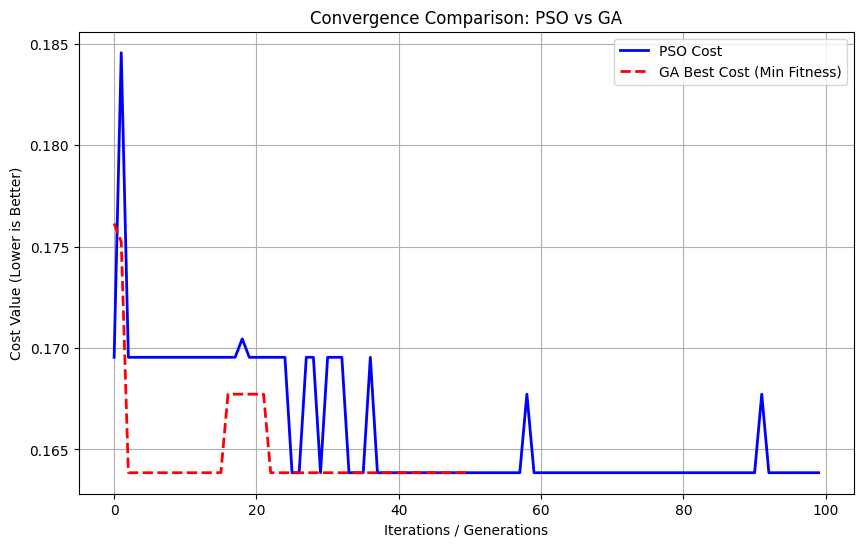

In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
import pyswarms as ps
from deap import base, creator, tools, algorithms
import random
import warnings

# غیرفعال کردن هشدارهای غیرضروری
warnings.filterwarnings("ignore")

# ==========================================
# بخش آ: بارگذاری و پیش‌پردازش داده‌ها
# ==========================================
def load_and_preprocess(filepath):
    # بارگذاری داده
    df = pd.read_csv(filepath)

    # حذف مقادیر NaN
    df.dropna(inplace=True)

    # تبدیل ستون‌های متنی به عددی
    le = LabelEncoder()
    categorical_cols = ['Gender', 'Married', 'Education', 'Self_Employed', 'Area', 'Status']

    # بررسی اینکه آیا ستون‌ها در دیتاست وجود دارند (ممکن است Dependents نیاز به پردازش خاص داشته باشد)
    for col in categorical_cols:
        if col in df.columns:
            df[col] = le.fit_transform(df[col])

    # ستون Dependents معمولا شامل '3+' است که باید هندل شود
    if 'Dependents' in df.columns:
        df['Dependents'] = df['Dependents'].replace('3+', 3).astype(int)

    # جدا کردن ویژگی‌ها و برچسب
    X = df.drop('Status', axis=1)
    y = df['Status']

    return X, y

# اجرای پیش‌پردازش
filename = 'loan_train.csv' # استفاده از فایل Train که لیبل دارد
X, y = load_and_preprocess(filename)
feature_names = X.columns.tolist()

# تقسیم داده‌ها (70% آموزش، 30% تست)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

print(f"Dataset Shape after cleaning: {X.shape}")
print(f"Features: {feature_names}")

# ==========================================
# تعریف تابع برازندگی (مشترک)
# ==========================================
def calculate_fitness(selected_features_binary, alpha=0.99):
    # اگر هیچ ویژگی انتخاب نشده باشد، هزینه بینهایت برگردان و دقت 0
    if np.sum(selected_features_binary) == 0:
        return 1.0, 0.0 # بدترین حالت (Cost 1, Accuracy 0)

    # انتخاب ستون‌ها بر اساس ماسک باینری
    cols_indices = [i for i, x in enumerate(selected_features_binary) if x == 1]

    X_train_sel = X_train.iloc[:, cols_indices]
    X_test_sel = X_test.iloc[:, cols_indices]

    # ساخت و آموزش مدل Random Forest
    clf = RandomForestClassifier(n_estimators=50, random_state=42, max_depth=5)
    clf.fit(X_train_sel, y_train)

    # پیش‌بینی و محاسبه دقت
    y_pred = clf.predict(X_test_sel)
    acc = accuracy_score(y_test, y_pred)

    # محاسبه تابع هزینه طبق فرمول سوال
    num_selected = len(cols_indices)
    total_features = len(selected_features_binary)

    j_cost = (alpha * (1 - acc)) + ((1 - alpha) * (num_selected / total_features))
    return j_cost, acc

# ==========================================
# بخش ب: الگوریتم PSO
# ==========================================
print("\nRunning PSO...")

# تابع هزینه مخصوص pyswarms (باید روی دسته‌ای از ذرات عمل کند)
def pso_fitness_function(particles):
    n_particles = particles.shape[0]
    j_costs = []
    for i in range(n_particles):
        # ذره‌ها در فضای پیوسته هستند، باید باینری شوند (آستانه 0.5)
        binary_mask = (particles[i] > 0.5).astype(int)
        cost, _ = calculate_fitness(binary_mask)
        j_costs.append(cost)
    return np.array(j_costs)

# تنظیمات PSO
options = {'c1': 0.5, 'c2': 0.3, 'w': 0.9, 'k': 2, 'p': 1}
dimensions = X.shape[1] # تعداد ابعاد برابر با تعداد ویژگی‌ها
optimizer = ps.discrete.binary.BinaryPSO(n_particles=50, dimensions=dimensions, options=options)

# اجرای بهینه‌سازی
best_cost_pso, best_pos_pso = optimizer.optimize(pso_fitness_function, iters=100, verbose=True)

# تاریخچه هزینه در خود آبجکت optimizer ذخیره شده است
cost_history_pso = optimizer.cost_history
# best_cost_pso و best_pos_pso مستقیماً از خروجی optimize() گرفته شده‌اند.
# آنها بهترین هزینه و بهترین موقعیت سراسری پیدا شده توسط PSO هستند.

# محاسبه دقت نهایی PSO با استفاده از بهترین موقعیت سراسری
final_cost_val_pso, final_acc_pso = calculate_fitness(best_pos_pso)
selected_indices_pso = [i for i, x in enumerate(best_pos_pso) if x == 1]
selected_features_pso_names = [feature_names[i] for i in selected_indices_pso]

# ==========================================
# بخش ج: الگوریتم GA (DEAP)
# ==========================================
print("\nRunning GA...")

# تعریف مسئله: کمینه‌سازی تابع هزینه
creator.create("FitnessMin", base.Fitness, weights=(-1.0,)) # وزن منفی برای کمینه‌سازی
creator.create("Individual", list, fitness=creator.FitnessMin)

toolbox = base.Toolbox()

# تعریف ژن و فرد (باینری)
toolbox.register("attr_bool", random.randint, 0, 1)
toolbox.register("individual", tools.initRepeat, creator.Individual, toolbox.attr_bool, n=dimensions)
toolbox.register("population", tools.initRepeat, list, toolbox.individual)

# تعریف تابع ارزیابی برای GA
def eval_ga(individual):
    cost, _ = calculate_fitness(individual)
    return (cost,)

toolbox.register("evaluate", eval_ga)
toolbox.register("mate", tools.cxTwoPoint)
toolbox.register("mutate", tools.mutFlipBit, indpb=0.1) # احتمال جهش برای هر بیت
toolbox.register("select", tools.selTournament, tournsize=3)

# پارامترهای GA
POP_SIZE = 50
NGEN = 50
CXPB = 0.9
MUTPB = 0.1

# اجرای GA
pop = toolbox.population(n=POP_SIZE)
hof = tools.HallOfFame(1) # نگهداری بهترین فرد
stats = tools.Statistics(lambda ind: ind.fitness.values)
stats.register("min", np.min)
stats.register("avg", np.mean)

pop, logbook = algorithms.eaSimple(pop, toolbox, cxpb=CXPB, mutpb=MUTPB, ngen=NGEN,
                                   stats=stats, halloffame=hof, verbose=False)

# استخراج نتایج GA
best_ind_ga = hof[0]
final_cost_val_ga, final_acc_ga = calculate_fitness(best_ind_ga)
selected_indices_ga = [i for i, x in enumerate(best_ind_ga) if x == 1]
selected_features_ga_names = [feature_names[i] for i in selected_indices_ga]

min_fitness_ga = logbook.select("min")

# ==========================================
# بخش د و ه: مقایسه و تحلیل
# ==========================================

print("-" * 30)
print("RESULTS SUMMARY")
print("-" * 30)

print(f"PSO Results:")
print(f"  - Final Accuracy: {final_acc_pso:.4f}")
print(f"  - Features Selected ({len(selected_features_pso_names)}): {selected_features_pso_names}")

print(f"\nGA Results:")
print(f"  - Final Accuracy: {final_acc_ga:.4f}")
print(f"  - Features Selected ({len(selected_features_ga_names)}): {selected_features_ga_names}")

# ==========================================
# بخش و: رسم نمودار مقایسه
# ==========================================
plt.figure(figsize=(10, 6))

# نمودار PSO (هزینه در طول تکرارها)
plt.plot(optimizer.cost_history, label='PSO Cost', color='blue', linewidth=2)

# نمودار GA (کمترین هزینه در هر نسل)
# چون تعداد نسل GA (50) کمتر از تکرار PSO (100) است، نمودار کوتاه‌تر خواهد بود
plt.plot(min_fitness_ga, label='GA Best Cost (Min Fitness)', color='red', linestyle='--', linewidth=2)

plt.title('Convergence Comparison: PSO vs GA')
plt.xlabel('Iterations / Generations')
plt.ylabel('Cost Value (Lower is Better)')
plt.legend()
plt.grid(True)
plt.show()